In [1]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import time_evolved_z_correlators as zc
from common_imports import *
import equilibrium_z_projectors as ez

In [ ]:
L = 300
taus =np.logspace(-2,3,100)

states_g0 = [kz.state(256,tau,tau) for tau in tqdm(taus)]
states_g1 = [kz.state(256,tau,0) for tau in tqdm(taus)]

100%|██████████| 100/100 [00:48<00:00,  2.05it/s]


In [ ]:
def helperz(states,n):
    return array([zc.P_n(n,s) for s in states])

/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/Adiabatic Approxmation Z projectors/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


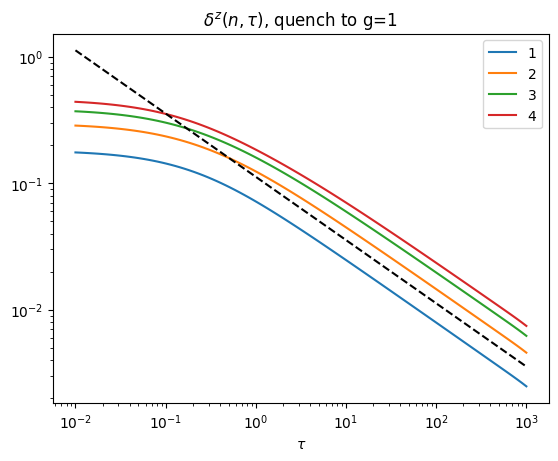

In [16]:

ns = np.arange(1,5)
for n in ns:
    plot(taus,np.abs(ez.P_n(n)-helperz(states_g1,n)),label=n)
legend()
loglog()
title(r"$\delta^z (n,\tau)$, quench to g=1")
xlabel(r"$\tau$")

pf1 = 1/2/sqrt(2)/pi
plot(taus,1*pf1*taus**(-1/2),"--k")
xscale("log")

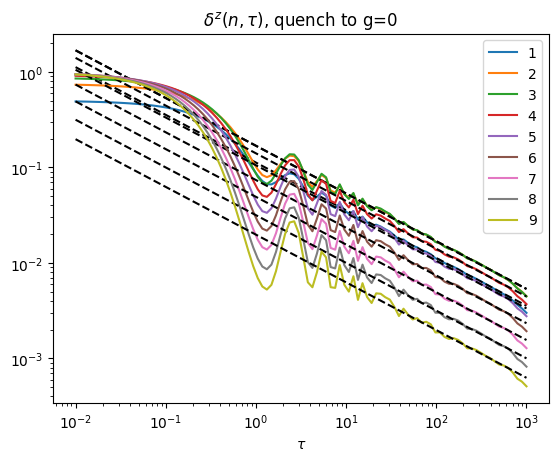

In [33]:

ns = [1,2,3,4,5,6,7,8,9]#np.arange(1,8)
for n in ns:
    plot(taus,np.abs(1/2**n -helperz(states_g0,n)),label=n)
    pf = n*(n+1)/2 * 2**(-n) * 1/pi/sqrt(2)
    plot(taus,pf*1/sqrt(taus),"--k")
    legend()
    title(r"$\delta^z (n,\tau)$, quench to g=0")
    xlabel(r"$\tau$")
    xscale("log")
    yscale("log")
    #show()

pf1 = 1/2/sqrt(2)/pi
#plot(taus,1*pf1*taus**(-1/2),"--k")

pf1 = sqrt(2)*3/8/pi
#plot(taus,1*pf1*taus**(-1/2),"--k")

pf1 = 21/64/sqrt(2)/pi
#plot(taus,1*pf1*taus**(-1/2),"--k")


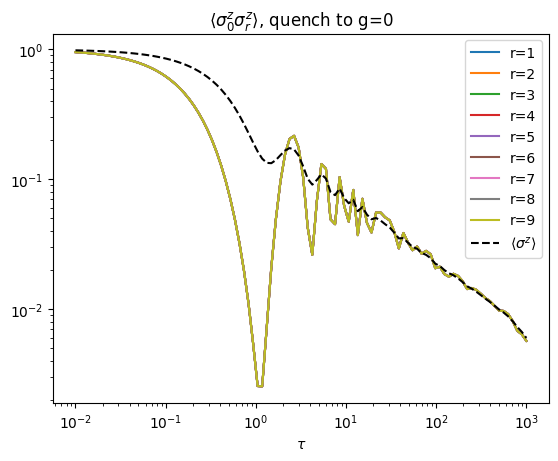

In [46]:
for n in ns:
    dat = [zc.sigma_general([0,1,2,3,4],s) for s in states_g0]
    plot(taus,dat,label=f"r={n}")
    #pf = n*(n+1)/2 * 2**(-n) * 1/pi/sqrt(2)
   #plot(taus,pf*1/sqrt(taus),"--k")
    title(r"$\langle \sigma^z_0 \sigma^z_{r} \rangle$, quench to g=0")
    xlabel(r"$\tau$")
    xscale("log")
    yscale("log")
    #show()

dat = [zc.sigma_general([0],s) for s in states_g0]
plot(taus,dat,"--k",label=r"$\langle \sigma^z \rangle$")
legend()


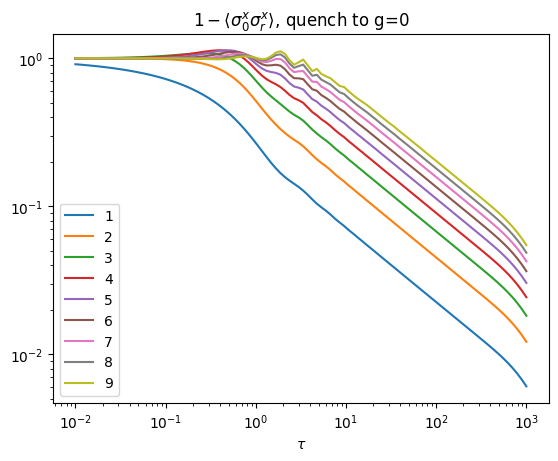

In [39]:
for n in ns:
    dat = [1-kz.sigma_general([0,n],s) for s in states_g0]
    plot(taus,dat,label=n)
    pf = n*(n+1)/2 * 2**(-n) * 1/pi/sqrt(2)
   #plot(taus,pf*1/sqrt(taus),"--k")
    legend()
    title(r"$1-\langle \sigma^x_0 \sigma^x_{r} \rangle$, quench to g=0")
    xlabel(r"$\tau$")
    xscale("log")
    yscale("log")
    #show()

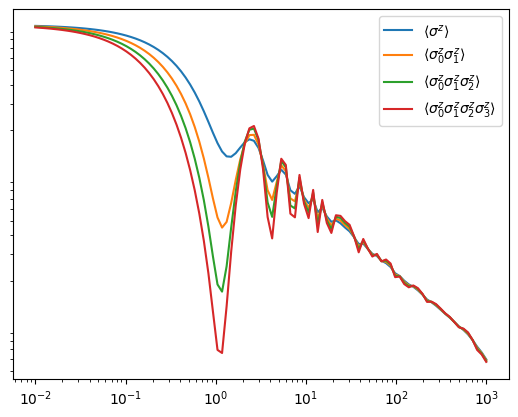

In [50]:


dat = [zc.sigma_general([0],s) for s in states_g0]
plot(taus,dat,label=r"$\langle \sigma^z \rangle$")


dat = [zc.sigma_general([0,1],s) for s in states_g0]
plot(taus,dat,label=r"$\langle \sigma^z_0 \sigma^z_1 \rangle$")
dat = [zc.sigma_general([0,1,2],s) for s in states_g0]
plot(taus,dat,label=r"$\langle \sigma^z_0 \sigma^z_1 \sigma^z_2 \rangle$")
dat = [zc.sigma_general([0,1,2,3],s) for s in states_g0]
plot(taus,dat,label=r"$\langle \sigma^z_0 \sigma^z_1 \sigma^z_2\sigma^z_3 \rangle$")
legend()
loglog("log")